In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(84).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(44).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(245).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/6.jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(238).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(196).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(108).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(310).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image (5).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(186).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(29).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(140).jpg
/kaggle/input/brain-tumor-classification-mri/Training/no_tumor/image(224).jpg

In [2]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# **Gerekli kütüphanelerden sonra sıradaki işlem verisetini yüklemek**


In [3]:
data={
    "train":"/kaggle/input/brain-tumor-classification-mri/Training",
    "test": "/kaggle/input/brain-tumor-classification-mri/Testing"
     }
labels=["glioma_tumor","meningioma_tumor","no_tumor","pituitary_tumor"]

In [4]:
#Veri yükleme fonksiyonu yapıyoruz.
def load_data(data,labels,img_size=224):
    X,y= [],[]
    for label in labels:
        path = os.path.join(data, label)
        for img_name in os.listdir(path):
            try:
                img = cv2.imread(os.path.join(path, img_name))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_size, img_size))
                X.append(img)
                y.append(labels.index(label))
            except Exception as e:
                print(f"Error loading image {img_name}: {e}")
    return np.array(X), np.array(y)
#Şimdi de veriyi yükleyelim
X_train, y_train=load_data(data["train"],labels)
X_test, y_test=load_data(data["test"],labels)

# Burada normalizasyon işlemi yaptık.

In [5]:
# Normalizasyon işlemi
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

One Hot Encoding işlemini yaptık

In [6]:
num_classes = len(labels)
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

Test ve eğitim olarak sınıflandırdık.

In [7]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

Veri arttırma işlemini yaptık

In [8]:
datagen = ImageDataGenerator(
    rotation_range=20,  
    width_shift_range=0.2,  
    height_shift_range=0.2,  
    shear_range=0.2,  
    zoom_range=0.2,  
    horizontal_flip=True,  
    fill_mode="nearest"
)
datagen.fit(X_train)

# Şimdi de görselleştirme işlemini yapalım

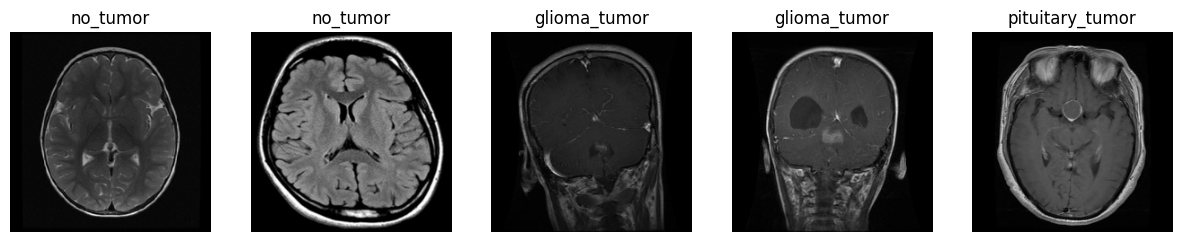

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(15, 5))  

for i in range(5):
    axes[i].imshow(X_train[i])
    axes[i].axis("off")
    axes[i].set_title(labels[np.argmax(y_train[i])])

plt.show()

# Şimdi de CNN modelini Oluşturalım.

In [10]:
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(224, 224, 3)),  # Burada input_shape yerine Input() kullandık.
    
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#Model optimizasyonu yapalım.Bunun için Adamw optimizasyonunu kullanalım.
from tensorflow.keras.optimizers import AdamW
model.compile(optimizer=AdamW(learning_rate=0.001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Burada da modelin eğitim işlemini gerçekleştiriyoruz.

In [12]:
import tensorflow as tf

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32)
val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.4590 - loss: 1.2781 - val_accuracy: 0.6254 - val_loss: 0.8154
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.6821 - loss: 0.7331 - val_accuracy: 0.8153 - val_loss: 0.5090
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.8159 - loss: 0.4797 - val_accuracy: 0.8171 - val_loss: 0.4701
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.8640 - loss: 0.3595 - val_accuracy: 0.8101 - val_loss: 0.4577
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.8908 - loss: 0.2860 - val_accuracy: 0.8606 - val_loss: 0.3546
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9190 - loss: 0.2272 - val_accuracy: 0.8502 - val_loss: 0.3795
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9341 - loss: 0.1850 - val_accuracy: 0.8902 - val_loss: 0.2851
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9526 - loss: 0.1333 - val_accuracy: 0.9059 - v

# Modelin testi ve performans analizini yapalım.

In [13]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 424ms/step - accuracy: 0.5221 - loss: 12.2507
Test Loss: 6.1400
Test Accuracy: 0.7259


13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 426ms/step


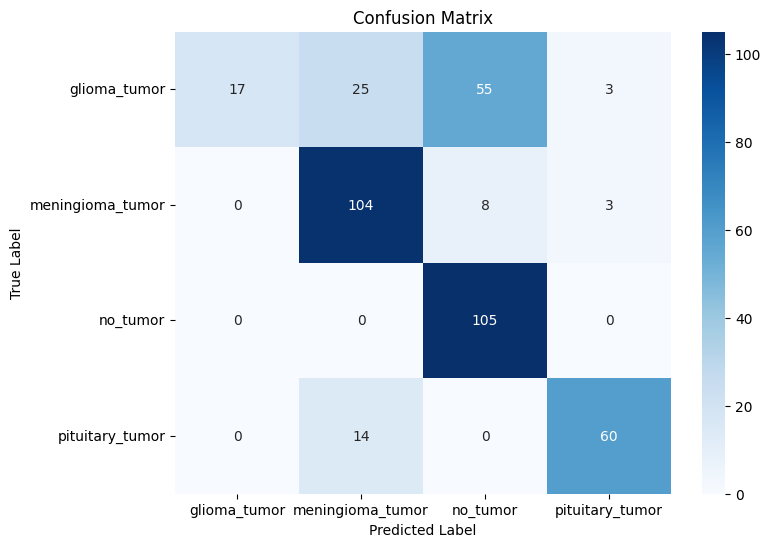

Classification Report:
                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.17      0.29       100
meningioma_tumor       0.73      0.90      0.81       115
        no_tumor       0.62      1.00      0.77       105
 pituitary_tumor       0.91      0.81      0.86        74

        accuracy                           0.73       394
       macro avg       0.82      0.72      0.68       394
    weighted avg       0.80      0.73      0.68       394



In [14]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=labels))